# Questão 1: Juntar todas as imagens em uma única

- Primeiramente, convertemos as imagens em arrays.
- Redimensionamos cada imagem para 500x500 pixels.
- Convertêmo-las para o formato RGB.
- Mostramos as imagens separadamente.
- Depois, unimos todas as imagens em uma só, utilizando os métodos hstack e vstack da biblioteca NumPy.
- Imprimimos a imagem final contendo todos os pinguins.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

In [2]:
NEW_SIZE = (500, 500)

p1_img = np.array(Image.open('P1.png').resize(NEW_SIZE))[:, :, :3]

p2_img = np.array(Image.open('P2.png').convert('RGB').resize(NEW_SIZE))[:, :, :3]

p3_img = np.array(Image.open('P3.jpg').resize(NEW_SIZE))[:, :, :3]

p4_img = np.array(Image.open('P4.png').resize(NEW_SIZE))[:, :, :3]

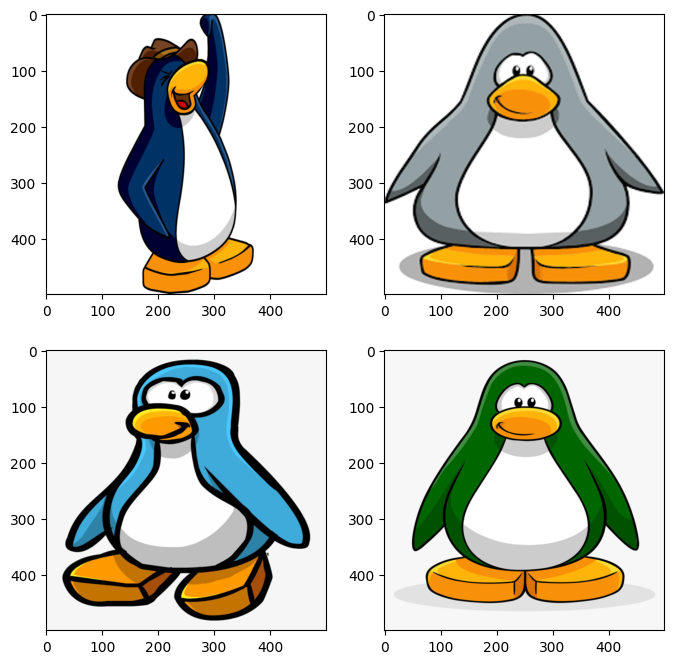

In [3]:
plt.figure(figsize=(8,8))

plt.subplot(2,2,1)
plt.imshow(p1_img)

plt.subplot(2,2,2)
plt.imshow(p2_img)

plt.subplot(2,2,3)
plt.imshow(p3_img)

plt.subplot(2,2,4)
plt.imshow(p4_img)

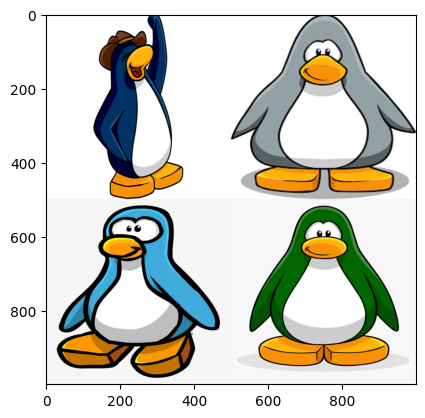

In [14]:
row1 = np.hstack((p1_img, p2_img))
row2 = np.hstack((p3_img, p4_img))
img = np.vstack((row1, row2))

plt.imshow(img)
plt.show()

# Questão 2: Trocar as cores

- Primeiramente convertemos a imagem para o espaço de cor HSV, usando a função conversaoHSV(), que transforma uma imagem RGB em HSV.
- Após a conversão, alteramos em 30 graus o matiz (hue) da imagem, provocando a troca de cores.
- Utilizamos a função conversaoRGB() para converter a imagem de volta para o formato RGB.
- Imprimimos a imagem com as cores alteradas.

In [21]:
def RGBtoHSV(imagem):
    img = np.array(imagem, dtype=np.float32) / 255.0
    
    r = img[..., 0]
    g = img[..., 1]
    b = img[..., 2]
    
    c_max = np.max(img, axis=-1)
    c_min = np.min(img, axis=-1)
    delta = c_max - c_min
    
    h = np.zeros_like(c_max)
    s = np.zeros_like(c_max)
    v = c_max
    
    mask = delta != 0
    h[mask & (c_max == r) & (g >= b)] = (60 * ((g - b) / delta))[mask & (c_max == r) & (g >= b)]
    h[mask & (c_max == r) & (g < b)] = (60 * ((g - b) / delta) + 360)[mask & (c_max == r) & (g < b)]
    h[mask & (c_max == g)] = (60 * ((b - r) / delta) + 120)[mask & (c_max == g)]
    h[mask & (c_max == b)] = (60 * ((r - g) / delta) + 240)[mask & (c_max == b)]
    
    s[c_max != 0] = delta[c_max != 0] / c_max[c_max != 0]
    return np.stack([h, s * 255, v * 255], axis=-1).astype(np.uint8)

def HSVtoRGB(hsv_img):
    h = hsv_img[..., 0].astype(np.float32)
    s = hsv_img[..., 1].astype(np.float32) / 255.0
    v = hsv_img[..., 2].astype(np.float32) / 255.0

    c = v * s
    x = c * (1 - np.abs((h / 60) % 2 - 1))
    m = v - c

    r = np.zeros_like(h)
    g = np.zeros_like(h)
    b = np.zeros_like(h)

    h0 = (h < 60)
    h1 = (h >= 60) & (h < 120)
    h2 = (h >= 120) & (h < 180)
    h3 = (h >= 180) & (h < 240)
    h4 = (h >= 240) & (h < 300)
    h5 = (h >= 300)

    r[h0], g[h0], b[h0] = c[h0], x[h0], 0
    r[h1], g[h1], b[h1] = x[h1], c[h1], 0
    r[h2], g[h2], b[h2] = 0, c[h2], x[h2]
    r[h3], g[h3], b[h3] = 0, x[h3], c[h3]
    r[h4], g[h4], b[h4] = x[h4], 0, c[h4]
    r[h5], g[h5], b[h5] = c[h5], 0, x[h5]

    r = (r + m) * 255
    g = (g + m) * 255
    b = (b + m) * 255

    rgb = np.stack([r, g, b], axis=-1).clip(0, 255).astype(np.uint8)
    return rgb

C:\Users\Victor\AppData\Local\Temp\ipykernel_336\1118548115.py:17: RuntimeWarning: invalid value encountered in divide
  h[mask & (c_max == r) & (g >= b)] = (60 * ((g - b) / delta))[mask & (c_max == r) & (g >= b)]
C:\Users\Victor\AppData\Local\Temp\ipykernel_336\1118548115.py:18: RuntimeWarning: invalid value encountered in divide
  h[mask & (c_max == r) & (g < b)] = (60 * ((g - b) / delta) + 360)[mask & (c_max == r) & (g < b)]
C:\Users\Victor\AppData\Local\Temp\ipykernel_336\1118548115.py:19: RuntimeWarning: invalid value encountered in divide
  h[mask & (c_max == g)] = (60 * ((b - r) / delta) + 120)[mask & (c_max == g)]
C:\Users\Victor\AppData\Local\Temp\ipykernel_336\1118548115.py:20: RuntimeWarning: invalid value encountered in divide
  h[mask & (c_max == b)] = (60 * ((r - g) / delta) + 240)[mask & (c_max == b)]


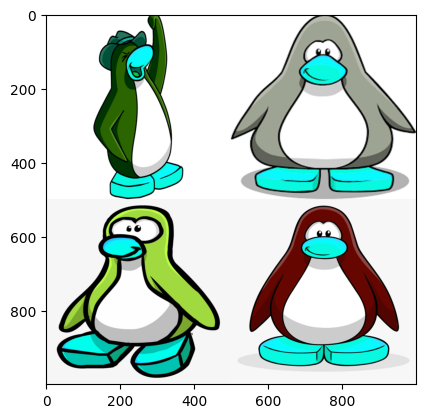

In [22]:
final = RGBtoHSV(img)
final[..., 0] = (final[..., 0] + 140) % 360
final = HSVtoRGB(final)

plt.imshow(final)
plt.show()

# Questão 3: Aplicar o espelhamento

- Realizamos a inversão dos valores da coluna (j) da imagem.
- Essa operação produziu um efeito de espelhamento vertical, como se a imagem fosse refletida em um espelho posicionado ao longo do eixo vertical.
- Imprimimos a imagem

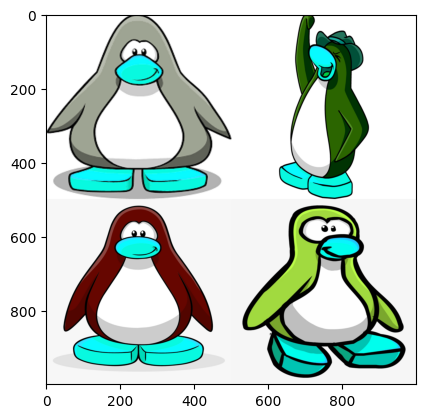

In [23]:
def refletir(img):
    (l, c, p) = img.shape
    
    reflexao = np.zeros(shape=img.shape, dtype=np.uint8)
    for i in range(l):
        for j in range(c):
            new_x = -j
            new_y = i
            reflexao[new_y, new_x] = img[i, j]

    return reflexao



final = refletir(final)

plt.imshow(final)
plt.show()

# Questão 4: Recortar seu pinguim favorito (descarte os outros, deixando apenas um na imagem).

- Recortamos a região das linhas entre 0 e 400 da imagem onde está o pinguim na parte exterior direita.
- Também selecionamos as colunas de 400 a 800.
- O recorte foi salvo na variável final.
- Imprimimos a imagem final

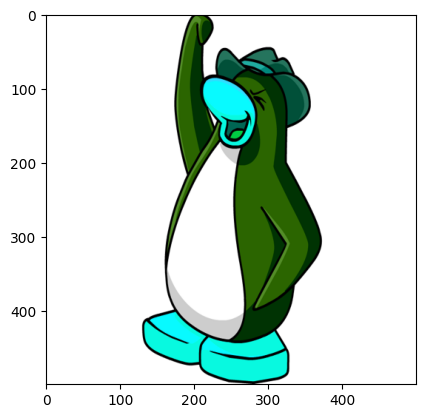

In [24]:
final = final[0:500, 500:1000]
plt.imshow(final)
plt.show()

# Questão 5: Faça a análise do histograma em seu pinguim favorito e escolha um valor de threshold.  (Justifique a escolha do threshold)

- Contamos quantos pixels existem para cada intensidade de cor (de 0 a 255).
- Apresentamos essa contagem no gráficos de barras (histogramas).
- Imprimimos tanto a imagem original quanto o gráfico.
- Convertemos a imagem para tons de cinza utilizando o método de lightness.
- Aplicamos um threshold (limiar) com valor 65 sobre a imagem em tons de cinza.
- Pixels com valor maior ou igual a 65 foram convertidos para branco (255).
- Pixels com valor menor que 65 foram convertidos para preto (0).
- O valor 65 foi escolhido por tentativa e erro.
- Imprimimos a imagem

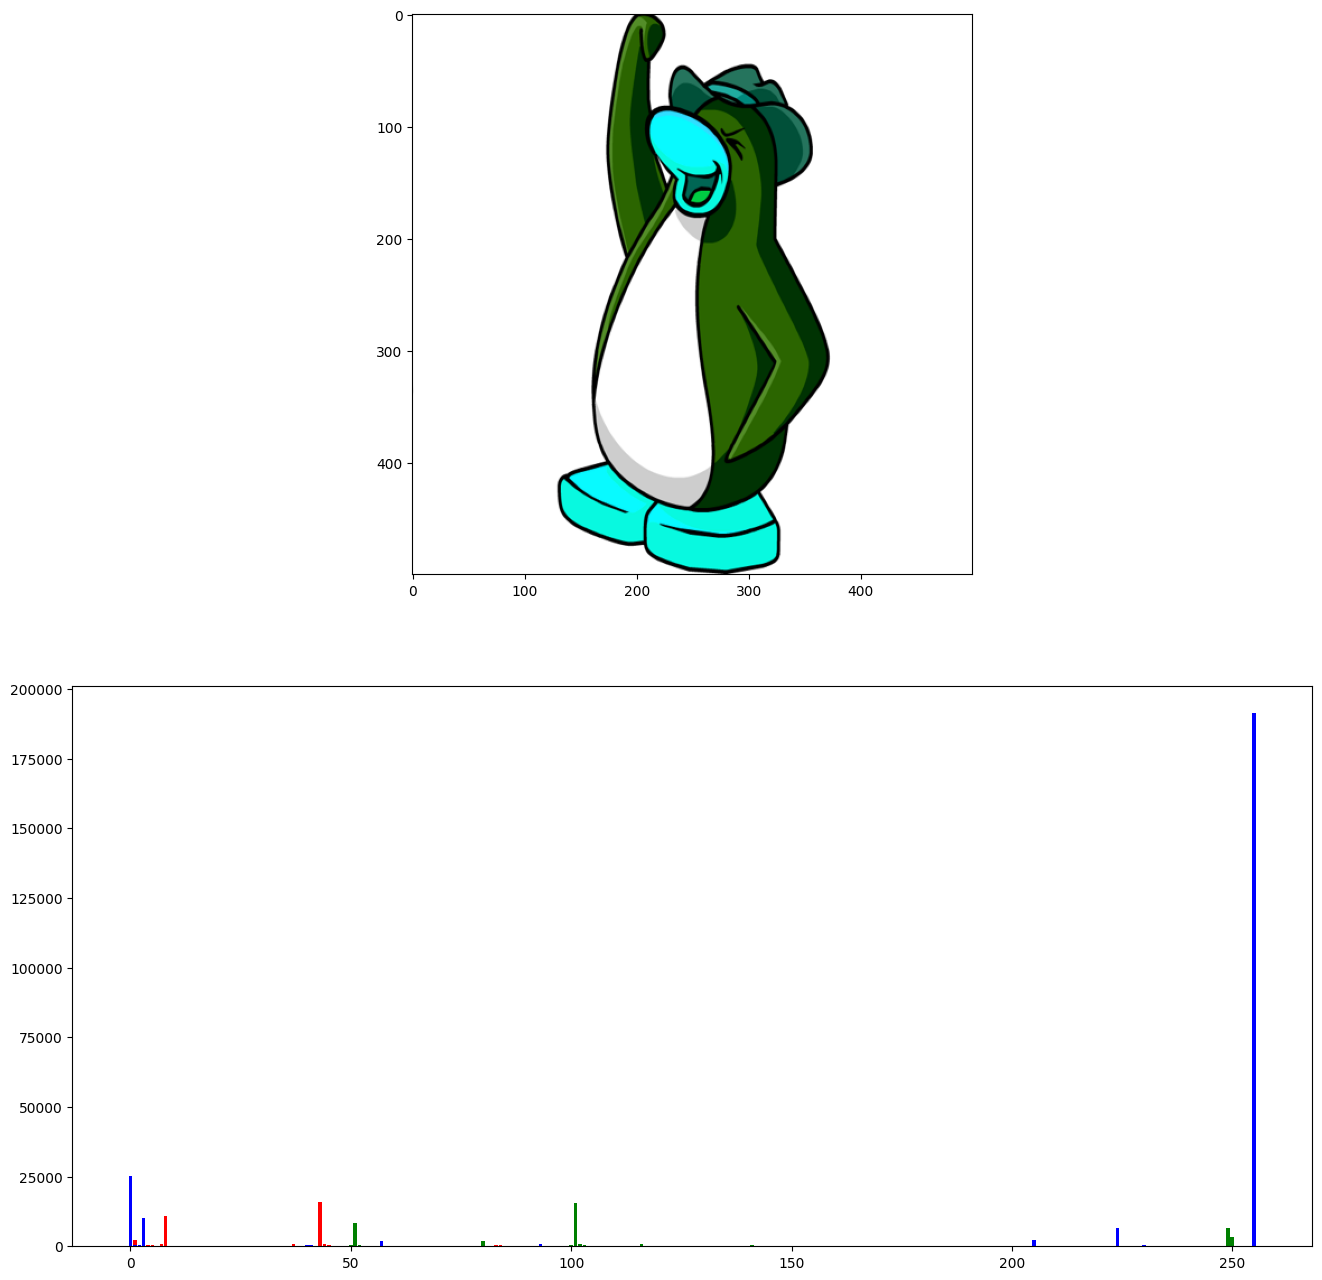

In [25]:
def histogram_gray(img):
    (l, c) = img.shape
    histogram = np.zeros(256, dtype=np.int32)

    for i in range(l):
        for j in range(c):
            intensity = img[i, j]
            histogram[intensity] += 1
            
    return histogram

def show_histogram_gray(img):
    histogram = histogram_gray(img)
    plt.figure(figsize=(16, 16))
    plt.subplot(2, 1, 1)
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.subplot(2, 1, 2)
    plt.bar(range(256), histogram)

def show_histogram(img):
    histogram_r = histogram_gray(img[:, :, 0])
    histogram_g = histogram_gray(img[:, :, 1])
    histogram_b = histogram_gray(img[:, :, 2])
    
    plt.figure(figsize=(16, 16))
    plt.subplot(2, 1, 1)
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.subplot(2, 1, 2)
    plt.bar(range(256), histogram_r, color='red')
    plt.bar(range(256), histogram_g, color='green')
    plt.bar(range(256), histogram_b, color='blue')



show_histogram(final)

In [26]:
THRESHOLD = 65

def apply_threshold(gray_img):
    binary_img = gray_img.copy()
    binary_img[gray_img >= THRESHOLD] = 255
    binary_img[gray_img < THRESHOLD] = 0
    return binary_img

def rgb_to_grayscale(img):
    return (0.2126 * img[:, :, 0] + 0.7152 * img[:, :, 1] + 0.0722 * img[:, :, 2]).astype(np.uint8)


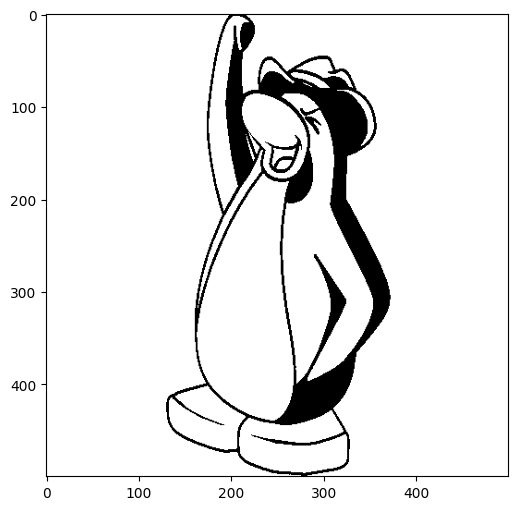

In [27]:
gray_img = rgb_to_grayscale(final)

plt.figure(figsize=(6, 6))
plt.imshow(apply_threshold(gray_img), cmap='gray', vmin=0, vmax=255)
plt.show()

# Questão 6: Aplique uma conversão para que todos os pixels abaixo dele sejam pintados de sua cor favorita (por exemplo: Azul)

- Aplicamos um valor de threshold à imagem.
- Apenas os pixels com intensidade abaixo de 65, receberam a cor [68, 14, 232].
- Os demais pixels (com intensidade igual ou superior a 65) ficam brancos.
- Imprimimos a imagem

In [28]:
def apply_threshold_with_color(gray_img, color):
    h, w = gray_img.shape
    return_img = np.ones((h, w, 3), dtype=np.uint8) * 255

    mask = gray_img < THRESHOLD

    return_img[mask] = color

    return return_img


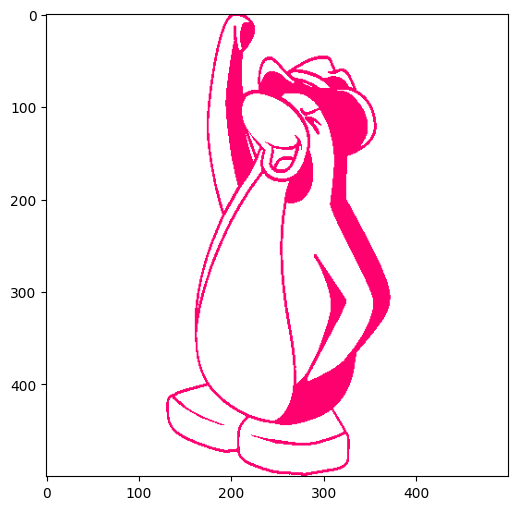

In [29]:
final = apply_threshold_with_color(gray_img, (255, 0, 111))

plt.figure(figsize=(6, 6))
plt.imshow(final)
plt.show()